In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load morphometry data
df_all_cores = pd.read_csv("foram_frag_morphometry.csv", encoding='latin-1')

/var/folders/ml/v613w2ns1z31hpn87j8vcl8h0000gq/T/ipykernel_13070/1822374775.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all_cores = pd.read_csv("foram_frag_morphometry.csv", encoding='latin-1')


In [3]:
# Separate foraminifera and fragment data
foram_data = df_all_cores[df_all_cores['Type'] == 'Planktonic Formainifera']
fragment_data = df_all_cores[df_all_cores['Type'] == 'Fragments']

In [4]:
# Drop rows with unknown Core ID
foram_data = foram_data[foram_data["Sample"] != "unknown"]
fragment_data = fragment_data[fragment_data["Sample"] != "unknown"]

In [ ]:
# Confirm unique core ids 
foram_data['Sample'].unique()

In [6]:
# Strictly retrieve Core Ids only
foram_data['core_id'] = foram_data['Sample'].apply(lambda x: x.split(" ")[0])
fragment_data['core_id'] = fragment_data['Sample'].apply(lambda x: x.split(" ")[0])

In [ ]:
# Replace wrong texts with their appropriate Core IDs in the Planktonic Formainifera data
foram_data['core_id'] = (foram_data['core_id'].replace("MD", "MD76-011")
                         .replace("MDB04-2873", "MD04-2873")
                         .replace("MD79-260d", "MD79-260")
                         .replace("BARDP9411", "BARP9411") 
                         .replace("MD90-O955", "MD90-0955") 
                         )


# Confirm string replacements
foram_data['core_id'].unique()

In [ ]:
# Replace wrong texts with their appropriate Core IDs in the fragments data
fragment_data['core_id'] = (fragment_data['core_id'].replace("MD", "MD76-011")
                         .replace("MDB04-2873", "MD04-2873")
                         .replace("MD79-260d", "MD79-260")
                         .replace("BARDP9411", "BARP9411") 
                         .replace("MD90-O955", "MD90-0955") 
                         )

# Confirm string replacements
fragment_data['core_id'].unique()

In [9]:
# Load data containing target Core IDs
df_target_cores = pd.read_csv("dissolution_manuscript_final.csv")

In [10]:
# Extract target core ids
target_cores = df_target_cores.iloc[ : , 0]
target_cores = list(target_cores)

In [11]:
# Create new planktonic foraminifera DataFrame based on target Core IDs
df_foram = foram_data[foram_data['core_id'].isin(target_cores)]

In [12]:
# Create new fragment DataFrame based on target Core IDs
df_fragment = fragment_data[fragment_data['core_id'].isin(target_cores)]

In [ ]:
# Confirm no target core is missing
missing_target_cores_foram = []

missing_target_cores_foram.extend(
    core for core in target_cores if core not in df_foram['core_id'].unique()
)

# Show list of missing target cores
print(missing_target_cores_foram) # Should return an empty list if no core is missing

In [14]:
# Confirm no target core is missing
missing_target_cores_frag = []

missing_target_cores_frag.extend(
    core for core in target_cores if core not in df_fragment['core_id'].unique()
)

# Show list of missing target cores
print(missing_target_cores_frag) # Should return an empty list if no core is missing

[]


In [15]:
# Group each data by sample (Core ID)
forams_grouped = df_foram.groupby('core_id')
fragments_grouped = df_fragment.groupby('core_id')

## Remove Outliers

In [16]:
def remove_outliers_iqr(df, column):
    """Removes outliers from a DataFrame column using the IQR method.

    Args:
        df: The Pandas DataFrame.
        column: The name of the column to remove outliers from.

    Returns:
        A new DataFrame with the outliers removed.
    """

    # Calculate quantiles and IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter data within bounds
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return df_filtered

In [18]:
def get_foram_working_data():
    """
    Processes foram data by removing outliers for each unique core_id and 
    concatenates the results into a single DataFrame.

    Returns:
        pd.DataFrame: A DataFrame containing the processed data for all samples.
    """
    result = pd.DataFrame()
    for sample in df_foram['core_id'].unique():
        foram_data = forams_grouped.get_group(sample)
        processed_data = remove_outliers_iqr(foram_data, 'Diameter')
        result = pd.concat([result, processed_data])
    return result

In [19]:
def get_frag_working_data():
    """
    Processes fragment data by removing outliers for each unique core_id and 
    concatenates the results into a single DataFrame.

    Returns:
        pd.DataFrame: A DataFrame containing the processed data for all samples.
    """
    frag_result = pd.DataFrame()
    for sample in df_fragment['core_id'].unique():
        fragment_data = fragments_grouped.get_group(sample)
        frag_processed_data = remove_outliers_iqr(fragment_data, 'Diameter')
        frag_result = pd.concat([frag_result, frag_processed_data])
    return frag_result

In [20]:
# Store groups without outliers in a new variable
foram_df_no_outliers = get_foram_working_data()
frag_df_no_outliers = get_frag_working_data()

In [21]:
# Create groups by unique core_id
foram_no_outlier_grouped = foram_df_no_outliers.groupby('core_id')
frag_no_outlier_grouped =  frag_df_no_outliers.groupby('core_id')

In [22]:
def get_mozambique_cores(foram_data, cores_list):
    """
    Extracts the Mozambique Channel cores from the foram data.
    
    Parameters:
        foram_data (pd.DataFrame): The foram data.
        cores_list (list): A list of core IDs to extract.
    
    Returns:
        pd.DataFrame: The subset of foram data corresponding to the Mozambique Channel cores.
    """
    return foram_data[foram_data['Sample'].isin(cores_list)]

### Fragment size distribution plots

In [ ]:
def plot_fragment_size_distribution(fragments_grouped, common_core_ids, subplots_per_plot=12):
    """
    Plots the fragment size distribution for each core_id in common_core_ids.
    
    Parameters:
    - frag_no_outlier_grouped: DataFrameGroupBy object containing the grouped fragment data.
    - common_core_ids: List of core IDs to plot.
    - subplots_per_plot: Number of subplots per plot (default is 12).
    """
    
    # Total number of core IDs
    total_core_ids = len(common_core_ids)

    # Number of plots needed
    num_plots = (total_core_ids + subplots_per_plot - 1) // subplots_per_plot

    # Iterate through each plot
    for plot_idx in range(num_plots):
        # Create a figure with subplots
        fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15))  # Adjust the grid size as needed
        axes = axes.flatten()
        
        # Iterate through each subplot
        for subplot_idx in range(subplots_per_plot):
            core_idx = plot_idx * subplots_per_plot + subplot_idx
            if core_idx < total_core_ids:
                core_id = common_core_ids[core_idx]
                fragment_data = fragments_grouped.get_group(core_id)
                
                # Plot the fragment size distribution in the current subplot
                sns.histplot(fragment_data['Diameter'], bins=30, kde=True, ax=axes[subplot_idx])
                axes[subplot_idx].set_title(f'Core ID: {core_id}', fontsize=15)
                axes[subplot_idx].set_xlabel('Fragment Diameter', fontsize=13)
                axes[subplot_idx].set_ylabel('Frequency', fontsize=13)
                axes[subplot_idx].tick_params(axis='both', labelsize=12)
            else:
                # Hide any unused subplots
                axes[subplot_idx].axis('off')
        
        # Adjust layout and show the plot
        plt.tight_layout()

        # Save the plot
        plt.savefig(f'fragment_size_distribution_plot_{plot_idx + 1}.png')

        plt.show()



# Get common core ids
common_core_ids = list(set(df_foram['core_id'].unique()) & set(df_fragment['core_id'].unique()))

# Plot Fragment Size Distribution
plot_fragment_size_distribution(fragments_grouped, common_core_ids)

### Fragment Fractal Models

In [ ]:
df_foram['core_id'].unique()

In [ ]:
from scipy.optimize import curve_fit

# Define the Power-Law with Exponential Cutoff function
def power_law_exponential_cutoff(x, alpha, beta, c):
    return c * (x ** -alpha) * np.exp(-beta * x)

# Function to fit the model to the data and plot the results
def fit_power_law_exponential_cutoff(fragment_data):
    # Extract the fragment sizes
    fragment_sizes = fragment_data['Diameter'].values
    
    # Define the bins for the histogram
    bins = np.logspace(np.log10(fragment_sizes.min()), np.log10(fragment_sizes.max()), 30)
    
    # Compute the histogram
    hist, bin_edges = np.histogram(fragment_sizes, bins=bins, density=True)
    
    # Compute the bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Fit the model to the data
    popt, pcov = curve_fit(power_law_exponential_cutoff, bin_centers, hist, p0=[1.0, 0.1, 1.0], maxfev=10000)
    
    # Extract the fitted parameters
    alpha, beta, c = popt
    
    return bin_centers, hist, alpha, beta, c

# Function to create subplots for multiple core IDs
def plot_multiple_cores(frag_no_outlier_grouped, common_core_ids, subplots_per_plot=12):
    # Total number of core IDs
    total_core_ids = len(common_core_ids)

    # Number of plots needed
    num_plots = (total_core_ids + subplots_per_plot - 1) // subplots_per_plot

    # List to store alpha and beta values
    alpha_beta_values = []

    # Iterate through each plot
    for plot_idx in range(num_plots):
        # Create a figure with subplots
        fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15))  # Adjust the grid size as needed
        axes = axes.flatten()
        
        # Iterate through each subplot
        for subplot_idx in range(subplots_per_plot):
            core_idx = plot_idx * subplots_per_plot + subplot_idx
            if core_idx < total_core_ids:
                core_id = common_core_ids[core_idx]
                fragment_data = frag_no_outlier_grouped.get_group(core_id)
                
                # Fit the model to the data
                bin_centers, hist, alpha, beta, c = fit_power_law_exponential_cutoff(fragment_data)
                
                # Store the alpha and beta values
                alpha_beta_values.append({'Core ID': core_id, 'Alpha': alpha, 'Beta': beta})

                # Plot the observed data and the fitted model in the current subplot
                axes[subplot_idx].loglog(bin_centers, hist, 'o', label='Observed Data')
                axes[subplot_idx].loglog(bin_centers, power_law_exponential_cutoff(bin_centers, alpha, beta, c), '-', label=f'Fitted Model\nalpha={alpha:.2f}, beta={beta:.2f}')
                axes[subplot_idx].set_title(f'Core ID: {core_id}', fontsize=15)
                axes[subplot_idx].set_xlabel('Fragment Diameter', fontsize=13)
                axes[subplot_idx].set_ylabel('Probability Density', fontsize=13)
                axes[subplot_idx].tick_params(axis='both', labelsize=12)
                axes[subplot_idx].legend()
            else:
                # Hide any unused subplots
                axes[subplot_idx].axis('off')
        
        # Adjust layout and show the plot
        plt.tight_layout()

        # Optionally, save the plot
        # plt.savefig(f'power_law_model_plots_{plot_idx + 1}.png')

        # Show the plot
        plt.show()
        
        

    alpha_beta_df = pd.DataFrame(alpha_beta_values)
    return alpha_beta_df

# Get common core ids
common_core_ids = list(set(df_foram['core_id'].unique()) & set(df_fragment['core_id'].unique()))

# Assuming frag_no_outlier_grouped is a DataFrameGroupBy object and common_core_ids is a list of core IDs
alpha_beta_df  = plot_multiple_cores(frag_no_outlier_grouped, common_core_ids)

# Set the option to display all rows
pd.set_option('display.max_rows', None)

# Display the DataFrame with alpha and beta values
print(alpha_beta_df)

# Save the DataFrame to an Excel file
alpha_beta_df.to_excel("alpha_beta_values.xlsx", index=False)

In [ ]:
alpha_beta_df.sort_values(by=['Alpha', 'Beta'])

In [27]:
alpha_beta_df['Beta'].max()

np.float64(2.5269108866967507)

In [28]:
alpha_values = alpha_beta_df["Alpha"]
alpha_lower_cutoff = np.percentile(alpha_values, 5)  # 5th percentile
alpha_upper_cutoff = np.percentile(alpha_values, 95)  # 95th percentile
alpha_df_filtered = alpha_beta_df[(alpha_beta_df["Alpha"] >= alpha_lower_cutoff) & (alpha_beta_df["Alpha"] <= alpha_upper_cutoff)]

In [29]:
mean_alpha = alpha_beta_df["Alpha"].mean()
std_alpha = alpha_beta_df["Alpha"].std()
z_cutoff_alpha = 2  # You can change this to 3 for a stricter filter

df_filtered = alpha_beta_df[(alpha_beta_df["Alpha"] > mean_alpha - z_cutoff_alpha * std_alpha) &
                 (alpha_beta_df["Alpha"] < mean_alpha + z_cutoff_alpha * std_alpha)]


In [30]:
# Create a DataFrame with the provided data

data = {
    'Core ID': [
        'MD96-2056', 'MD77-171', 'MD79-276', 'MD90-0938', 'MD77-184', 'MD79-260', 'MD79-261',
        'MD96-2063', 'MD96-2067b', 'MD76-132', 'MD77-182', 'MD12-3423', 'BARP9437', 'MD96-2053',
        'BARP9411', 'MD04-2875B', 'BARP9409', 'MD90-0956', 'BARP9442', 'MD96-2045', 'MD77-202',
        'MD77-160', 'BARP9422', 'MD96-2055', 'MD96-2066', 'MD96-2051', 'MD90-0955', 'MD04-2877',
        'MD77-205', 'MD96-2061', 'MD76-011', 'MD90-0940', 'BARP9441', 'MD77-185', 'MD96-2054',
        'MD96-2044', 'MD96-2059', 'MD98-2165', 'MD79-257', 'MD96-2067a', 'BARP9426', 'BARP9412',
        'MD77-204', 'MD90-0939', 'MD90-0958', 'MD96-2049', 'BARP9430', 'MD90-0949', 'MD04-2873',
        'MD96-2058', 'MD96-2060', 'MD76-133', 'MD90-0936', 'MD90-0959', 'MD90-0960', 'MD96-2067b2',
        'MD96-2064', 'MD96-2065', 'MD90-0957', 'MD90-0961', 'MD90-0963', 'BARP9439'
    ],
    'Alpha': [
        -18.108650, -59.675240, -20.244363, -16.053934, -19.723482, -19.116017, -17.618696,
        -20.119371, -20.347793, -18.385484, -19.094018, -14.095055, -24.475254, -15.038397,
        -24.490918, -36.085941, -31.693948, -18.204009, -20.810424, -18.157425, -38.038229,
        -19.512952, -21.007201, -20.660047, -19.398866, -26.840740, -27.051262, -26.162899,
        -18.139061, -18.671537, -22.402200, -17.119990, -24.282491, -14.018848, -20.826218,
        -24.781504, -16.432166, -47.543768, -26.540595, -14.959702, -28.689328, -29.763404,
        -20.928647, -16.318197, -27.746896, -16.706299, -15.534841, -16.309463, -25.450741,
        -10.510314, -17.407659, 0.811169, -18.971236, -19.058695, -24.362528, -23.997345,
        -24.800059, -18.432012, -21.791071, -18.399807, -13.982205, -33.622183
    ],
    'Beta': [
        0.076074, 2.526911, 0.079420, 0.062156, 0.077071, 0.070689, 0.073516,
        0.093577, 0.087612, 0.076194, 0.077525, 0.060115, 0.107584, 0.057754,
        0.108145, 0.164885, 0.126400, 0.072886, 0.085831, 0.073684, 0.163262,
        0.071081, 0.079556, 1.639543, 0.086847, 0.113985, 0.117351, 0.113199,
        0.072321, 0.083844, 0.086099, 0.060660, 0.098146, 0.057912, 0.087003,
        0.102145, 0.072410, 0.200487, 0.117153, 0.059892, 0.115217, 0.127875,
        0.085537, 0.059510, 0.117290, 0.073214, 1.267019, 0.064448, 0.110839,
        0.039074, 0.074607, 0.091174, 0.076349, 0.071948, 0.100605, 0.096122,
        0.116314, 0.076484, 0.087879, 0.077758, 0.057057, 0.142281
    ]
}

df = pd.DataFrame(data)

# Classify the cores based on Alpha and Beta values
def classify_core(alpha, beta):
    # Category 1: Exponential Cutoff Dominant
    # Cases with very high Beta values showing extreme dissolution thresholds
    if beta >= 1.0:
        return "Dominant Exponential Cutoff"
    
    # Category 2: Strong Power Law with Dissolution
    # Combines steep power law decline (very negative Alpha) with significant Beta
    elif alpha < -30 and beta >= 0.1:
        return "Strong Exponential Cutoff"
    # Category 3: Moderate Power Law with Dissolution
    # Moderate Alpha and Beta values representing intermediate dissolution effects
    elif -30 <= alpha < -15 and beta >= 0.05:
        return "Varying Power Law and Exponential Cutoffs"
    
    # Category 4: Weak/Anomalous Dissolution Patterns
    # Either minimal dissolution (small negative Alpha) or unusual patterns
    else:
        return "Uniform but moderate Exponential Cutoff"


df['Classification'] = df.apply(lambda row: classify_core(row['Alpha'], row['Beta']), axis=1)

# Display the classified DataFrame
df

,Core ID,Alpha,Beta,Classification
0,MD96-2056,-18.108650,0.076074,Varying Power Law and Exponential Cutoffs
1,MD77-171,-59.675240,2.526911,Dominant Exponential Cutoff
2,MD79-276,-20.244363,0.079420,Varying Power Law and Exponential Cutoffs
3,MD90-0938,-16.053934,0.062156,Varying Power Law and Exponential Cutoffs
4,MD77-184,-19.723482,0.077071,Varying Power Law and Exponential Cutoffs
5,MD79-260,-19.116017,0.070689,Varying Power Law and Exponential Cutoffs
6,MD79-261,-17.618696,0.073516,Varying Power Law and Exponential Cutoffs
7,MD96-2063,-20.119371,0.093577,Varying Power Law and Exponential Cutoffs
8,MD96-2067b,-20.347793,0.087612,Varying Power Law and Exponential Cutoffs
9,MD76-132,-18.385484,0.076194,Varying Power Law and Exponential Cutoffs


Alpha Threshold = -25:
  Varying Power Law and Exponential Cutoff Strengths: 40
  Strong Exponential Cutoff: 13
  Uniform but moderate Exponential Cutoff: 6
  Dominant Exponential Cutoff: 3

Alpha Threshold = -26:
  Varying Power Law and Exponential Cutoff Strengths: 41
  Strong Exponential Cutoff: 12
  Uniform but moderate Exponential Cutoff: 6
  Dominant Exponential Cutoff: 3

Alpha Threshold = -27:
  Varying Power Law and Exponential Cutoff Strengths: 44
  Strong Exponential Cutoff: 9
  Uniform but moderate Exponential Cutoff: 6
  Dominant Exponential Cutoff: 3

Alpha Threshold = -28:
  Varying Power Law and Exponential Cutoff Strengths: 46
  Strong Exponential Cutoff: 7
  Uniform but moderate Exponential Cutoff: 6
  Dominant Exponential Cutoff: 3

Alpha Threshold = -29:
  Varying Power Law and Exponential Cutoff Strengths: 47
  Uniform but moderate Exponential Cutoff: 6
  Strong Exponential Cutoff: 6
  Dominant Exponential Cutoff: 3

Alpha Threshold = -30:
  Varying Power Law and E

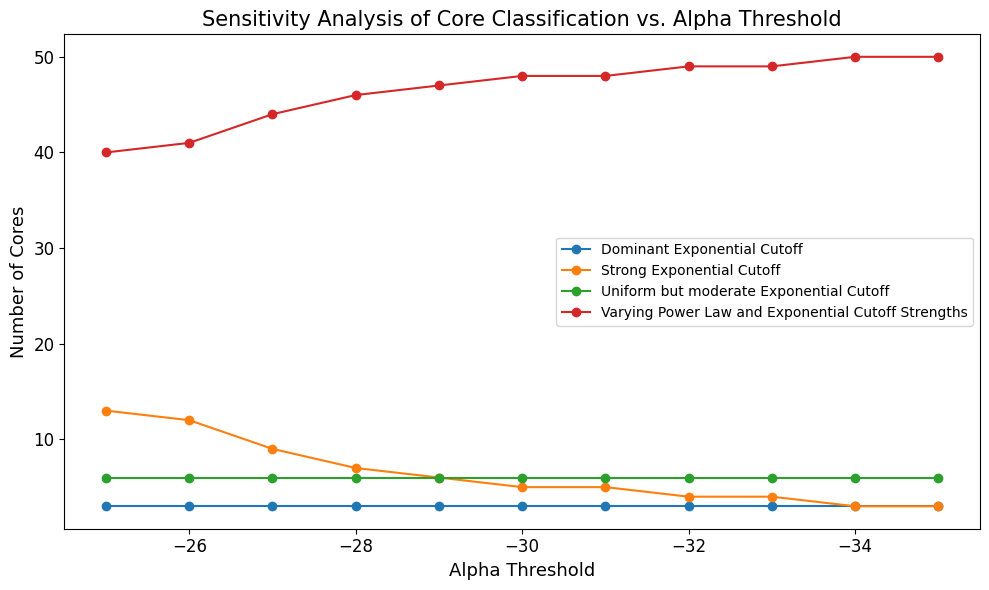

In [31]:
# Define a classification function that takes an adjustable alpha threshold
def classify_core(alpha, beta, alpha_threshold):
    # Category 1: Exponential Cutoff Dominant (Beta >=1 implies extreme dissolution)
    if beta >= 1.0:
        return "Dominant Exponential Cutoff"
    # Category 2: Strong Power Law with Dissolution (alpha very negative, below the threshold)
    elif alpha < alpha_threshold and beta >= 0.1:
        return "Strong Exponential Cutoff"
    # Category 3: Moderate Power Law with Dissolution (alpha between threshold and -15)
    elif alpha_threshold <= alpha < -15 and beta >= 0.05:
        return "Varying Power Law and Exponential Cutoff Strengths"
    # Category 4: Weak/Anomalous Dissolution Patterns
    else:
        return "Uniform but moderate Exponential Cutoff"

# Create a function to run the sensitivity analysis over a range of alpha thresholds
def sensitivity_analysis(df, alpha_thresholds):
    results = {}
    for threshold in alpha_thresholds:
        # Classify using the current threshold
        df['Classification'] = df.apply(lambda row: classify_core(row['Alpha'], row['Beta'], threshold), axis=1)
        # Count each category
        counts = df['Classification'].value_counts().to_dict()
        results[threshold] = counts
    return results

# Define a range of alpha_threshold values to test, e.g., from -25 to -35
alpha_thresholds = list(range(-25, -36, -1))
analysis_results = sensitivity_analysis(df, alpha_thresholds)

# Display the results
for threshold, counts in analysis_results.items():
    print(f"Alpha Threshold = {threshold}:")
    for classification, count in counts.items():
        print(f"  {classification}: {count}")
    print()

# Optionally, plot the sensitivity analysis results
import matplotlib.pyplot as plt

categories = set()
for counts in analysis_results.values():
    categories.update(counts.keys())
categories = sorted(list(categories))

# For each category, prepare a list of counts for each threshold.
thresholds = sorted(analysis_results.keys())
plot_data = {cat: [] for cat in categories}

for thr in thresholds:
    counts = analysis_results[thr]
    for cat in categories:
        plot_data[cat].append(counts.get(cat, 0))

plt.figure(figsize=(10, 6))
for cat, counts in plot_data.items():
    plt.plot(thresholds, counts, marker='o', label=cat)

plt.xlabel('Alpha Threshold', fontsize=13)
plt.ylabel('Number of Cores', fontsize=13)
plt.tick_params(axis='both', labelsize=12)
plt.title('Sensitivity Analysis of Core Classification vs. Alpha Threshold', fontsize=15)
plt.legend()
plt.gca().invert_xaxis()  # Invert x-axis if you want higher (more negative) thresholds on the left.
plt.tight_layout()
# plt.savefig('sensitivity_analysis_plot.png')
plt.show()

In [32]:
df['Classification'].value_counts()

Classification
Varying Power Law and Exponential Cutoff Strengths    50
Uniform but moderate Exponential Cutoff                6
Dominant Exponential Cutoff                            3
Strong Exponential Cutoff                              3
Name: count, dtype: int64

In [ ]:
from scipy.optimize import curve_fit

# Define the Power-Law with Exponential Cutoff function
def power_law_exponential_cutoff(x, alpha, beta, c):
    return c * (x ** -alpha) * np.exp(-beta * x)

# Function to fit the model to the data and plot the results
def fit_power_law_exponential_cutoff(fragment_data):
    # Extract the fragment sizes
    fragment_sizes = fragment_data['Diameter'].values
    
    # Define the bins for the histogram
    bins = np.logspace(np.log10(fragment_sizes.min()), np.log10(fragment_sizes.max()), 30)
    
    # Compute the histogram
    hist, bin_edges = np.histogram(fragment_sizes, bins=bins, density=True)
    
    # Compute the bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Fit the model to the data
    popt, pcov = curve_fit(power_law_exponential_cutoff, bin_centers, hist, p0=[1.0, 0.1, 1.0], maxfev=10000)
    
    # Extract the fitted parameters
    alpha, beta, c = popt
    
    return bin_centers, hist, alpha, beta, c


# Function to create subplots for multiple core IDs
def plot_multiple_cores(frag_no_outlier_grouped, cores_list, subplots_per_plot=8):
    # Total number of core IDs
    total_core_ids = len(cores_list)

    # Number of plots needed
    num_plots = (total_core_ids + subplots_per_plot - 1) // subplots_per_plot

    # List to store alpha and beta values
    alpha_beta_values = []

    # Iterate through each plot
    for plot_idx in range(num_plots):
        # Create a figure with subplots
        fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 9))  # Adjust the grid size as needed
        axes = axes.flatten()
        
        # Iterate through each subplot
        for subplot_idx in range(subplots_per_plot):
            core_idx = plot_idx * subplots_per_plot + subplot_idx
            if core_idx < total_core_ids:
                core_id = cores_list[core_idx]
                fragment_data = frag_no_outlier_grouped.get_group(core_id)
                
                # Fit the model to the data
                bin_centers, hist, alpha, beta, c = fit_power_law_exponential_cutoff(fragment_data)
                
                # Store the alpha and beta values
                alpha_beta_values.append({'Core ID': core_id, 'Alpha': alpha, 'Beta': beta})

                # Plot the observed data and the fitted model in the current subplot
                axes[subplot_idx].loglog(bin_centers, hist, 'o', label='Observed Data')
                axes[subplot_idx].loglog(bin_centers, power_law_exponential_cutoff(bin_centers, alpha, beta, c), '-', label=f'Fitted Model\nalpha={alpha:.2f}, beta={beta:.2f}')
                axes[subplot_idx].set_title(f'Core ID: {core_id}', fontsize=15)
                axes[subplot_idx].set_xlabel('Fragment Diameter', fontsize=13)
                axes[subplot_idx].set_ylabel('Probability Density', fontsize=13)
                axes[subplot_idx].tick_params(axis='both', labelsize=12)
                axes[subplot_idx].legend()
            else:
                # Hide any unused subplots
                axes[subplot_idx].axis('off')
        
        # Adjust layout and show the plot
        plt.tight_layout()

        # Optionally, save the plot
        # plt.savefig(f'selected_power_law_model_plots_{plot_idx + 1}.png')

        # Show the plot
        plt.show()
        
        

    alpha_beta_df = pd.DataFrame(alpha_beta_values)
    return alpha_beta_df

# Get common core ids
cores_list=  ['MD96-2055', 'BARP9439',  'MD90-0940', 'MD77-185', 'MD77-171',  'BARP9409',  "MD76-011",  'MD96-2058']

# Assuming frag_no_outlier_grouped is a DataFrameGroupBy object and common_core_ids is a list of core IDs
plot_multiple_cores(frag_no_outlier_grouped, cores_list)


## Run Vif (multicollinearity test)

### Forams

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

def calculate_vif(df, features):
    """Calculates VIF for specified features in a DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing the features.
        features (list): List of feature names for VIF calculation.

    Returns:
        pd.DataFrame: VIF results for each feature.
    """

    X = df[features]  # Select features for VIF
    X = X.dropna()  # Drop rows with missing values


    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Create a DataFrame with the standardized data
    X_scaled_df = pd.DataFrame(X_scaled, columns=features)

    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_scaled_df.columns
    vif_data['VIF'] = [variance_inflation_factor(X_scaled_df.values, i) for i in range(X_scaled_df.shape[1])]

    return vif_data

In [34]:
def create_vif_data():
    all_features = []  # List to store features for each sample

    for sample in foram_df_no_outliers['core_id'].unique():
        # Forams metrics
        foram_data = foram_no_outlier_grouped.get_group(sample)
        variance_forams = np.var(foram_data['Diameter'], ddof=1)  # Sample variance
        diameter_forams = foram_data['Diameter'].mean()
        circularity_forams = foram_data['Circularity'].mean()
        solidity_forams = foram_data['Solidity '].mean()
        eccentricity_forams = foram_data['Eccentricity'].mean()
        area_forams = foram_data['Areamm2'].mean()
        perimeter_forams = foram_data['Perimeterm2'].mean()
        roundness_forams = foram_data['Roundnessm'].mean()
        kurtosis_forams = foram_data['Kurtosis'].mean()

        # Append the feature list for the current sample
        all_features.append([variance_forams,  circularity_forams, 
                             
                             roundness_forams,   kurtosis_forams
        ])
    # diameter_forams, area_forams, eccentricity_forams,solidity_forams, perimeter_forams,
    # Create DataFrame after collecting all features
    vif_data = pd.DataFrame(all_features, columns=['variance_forams', 'circularity_forams',                            
                            'roundness_forams', 'kurtosis_forams'
    ])

    return vif_data

In [35]:
df_foram_X = create_vif_data()
feature_foram = ['variance_forams', 'circularity_forams', 
            
            'roundness_forams',  'kurtosis_forams'
        ]

calculate_vif(df_foram_X, feature_foram)

,Feature,VIF
0,variance_forams,1.505644
1,circularity_forams,1.974038
2,roundness_forams,1.899481
3,kurtosis_forams,1.904695


## Fragments

In [36]:
def create_frag_vif_data():
    all_features = []  # List to store features for each sample

    for sample in frag_df_no_outliers['core_id'].unique():
        # Forams metrics
        fragment_data = frag_no_outlier_grouped.get_group(sample)
        variance_frag = np.var(fragment_data['Diameter'], ddof=1)  # Sample variance
        diameter_frag = fragment_data['Diameter'].mean()
        circularity_frag = fragment_data['Circularity'].mean()
        solidity_frag = fragment_data['Solidity '].mean()
        eccentricity_frag = fragment_data['Eccentricity'].mean()
        area_frag = fragment_data['Areamm2'].mean()
        perimeter_frag = fragment_data['Perimeterm2'].mean()
        roundness_frag = fragment_data['Roundnessm'].mean()
        kurtosis_frag = fragment_data['Kurtosis'].mean()

        # Append the feature list for the current sample
        all_features.append([variance_frag, diameter_frag, circularity_frag,
              eccentricity_frag, kurtosis_frag,
              
        ])
    # area_frag, perimeter_frag, roundness_frag, solidity_frag, 
    # Create DataFrame after collecting all features
    frag_vif_data = pd.DataFrame(all_features, columns=[
    'variance_frag', 'diameter_frag', 'circularity_frag',
              'eccentricity_frag', 'kurtosis_frag',              
            
    ])

    return frag_vif_data

In [37]:
df_frag_X = create_frag_vif_data()
feature_frag = ['variance_frag', 'diameter_frag', 'circularity_frag',
              'eccentricity_frag', 'kurtosis_frag', 
               ]

calculate_vif(df_frag_X, feature_frag)

,Feature,VIF
0,variance_frag,3.384251
1,diameter_frag,3.897335
2,circularity_frag,2.809004
3,eccentricity_frag,4.162603
4,kurtosis_frag,1.584891


## Forams + Fragments

In [38]:
def create_full_vif_data():
    all_features = []  # List to store features for each core/sample

    # Get the common core IDs present in both datasets
    common_core_ids = set(df_foram['core_id'].unique()) & set(df_fragment['core_id'].unique())

    for core_id in common_core_ids:
        # Forams metrics
        foram_data = foram_no_outlier_grouped.get_group(core_id)
        variance_forams = np.var(foram_data['Diameter'], ddof=1)  # Sample variance
        diameter_forams = foram_data['Diameter'].mean()
        circularity_forams = foram_data['Circularity'].mean()
        solidity_forams = foram_data['Solidity '].mean()  # Removed extra space
        eccentricity_forams = foram_data['Eccentricity'].mean()
        area_forams = foram_data['Areamm2'].mean()
        perimeter_forams = foram_data['Perimeterm2'].mean()
        roundness_forams = foram_data['Roundnessm'].mean()
        kurtosis_forams = foram_data['Kurtosis'].mean()
        
        # Fragments metrics
        fragment_data = frag_no_outlier_grouped.get_group(core_id)
        variance_frag = np.var(fragment_data['Diameter'], ddof=1)
        diameter_frag = fragment_data['Diameter'].mean()
        circularity_frag = fragment_data['Circularity'].mean()
        solidity_frag = fragment_data['Solidity '].mean()
        eccentricity_frag = fragment_data['Eccentricity'].mean()
        area_frag = fragment_data['Areamm2'].mean()
        perimeter_frag = fragment_data['Perimeterm2'].mean()
        roundness_frag = fragment_data['Roundnessm'].mean()
        kurtosis_frag = fragment_data['Kurtosis'].mean()

        # Append combined features
        all_features.append([
            variance_forams, circularity_forams, eccentricity_forams,
             kurtosis_forams,
            variance_frag, circularity_frag, eccentricity_frag,
             kurtosis_frag
        ])

    # Create DataFrame after collecting all features
    full_vif_data = pd.DataFrame(all_features, columns=[
        'variance_forams', 'circularity_forams',
        'eccentricity_forams',  'kurtosis_forams',
        'variance_frag', 'circularity_frag', 
        'eccentricity_frag', 'kurtosis_frag'
    ])
    
    return full_vif_data


In [39]:
df_full_X = create_full_vif_data()
feature = ['variance_forams', 'circularity_forams', 
        'eccentricity_forams',  'kurtosis_forams',
        'variance_frag',  'circularity_frag', 
        'eccentricity_frag', 'kurtosis_frag']

calculate_vif(df_full_X, feature)

,Feature,VIF
0,variance_forams,2.703949
1,circularity_forams,3.891705
2,eccentricity_forams,2.164676
3,kurtosis_forams,2.819703
4,variance_frag,1.995146
5,circularity_frag,3.519950
6,eccentricity_frag,3.427960
7,kurtosis_frag,4.395134


## Dissolution Indices Re-calculated 

In [40]:
# Create a global rank
species_order = [
    'Globigerinoides ruber', 'Globoturborotalita rubescens', 'Globoturborotalita tenella',
    'Globigerinella siphonifera', 'Globigerinoides sacculifer', 'Globigerinoides conglobatus',
    'Globigerina bulloides', 'Globigerinita glutinata', 'Globigerina falconensis',
    'Orbulina universa', 'Globorotalia scitula', 'Globoquadrina conglomerata', 
    'Globorotalia hirsuta', 'Globorotalia truncatulinoides', 'Globorotalia inflata', 
    'Globorotalia menardii', 'Globorotalia crassaformis', 'Neogloboquadrina dutertrei', 
    'Neogloboquadrina incompta', 'Pulleniatina obliquiloculata', 'Globorotalia tumida', 'Turborotalita humilis',
]

susceptible_species = [
    'Globigerinoides ruber', 'Globoturborotalita rubescens', 'Globoturborotalita tenella',
    'Globigerinella siphonifera', 'Globigerinoides sacculifer', 'Globigerinoides conglobatus',
    'Globigerina bulloides', 'Globigerinita glutinata', 'Globigerina falconensis',
    'Orbulina universa', 'Globorotalia scitula',
]

resistant_species = [
    'Globoquadrina conglomerata', 'Globorotalia hirsuta', 'Globorotalia truncatulinoides', 
    'Globorotalia inflata', 'Globorotalia menardii', 'Globorotalia crassaformis', 
    'Neogloboquadrina dutertrei', 'Neogloboquadrina incompta', 'Pulleniatina obliquiloculata', 
    'Globorotalia tumida', 'Turborotalita humilis',
]

global_rank = {species: rank + 1 for rank, species in enumerate(species_order)}

def clean_species_name(name):
    """
    Cleans the species name to match the format in the global rank.
    
    Args:
        name (str): The species name to clean.
    
    Returns:
        str: The cleaned species name.
    """
    return ' '.join(name.split()).replace('_', ' ')

def calculate_dissolution_indices():  
    """
    Calculates various dissolution indices for common core IDs in the datasets.

    Returns:
        pd.DataFrame: A DataFrame containing the dissolution indices for each core ID.
    """
    indices = {
        'Core ID': [],
        'FV-Index_0': [],
        'FV-Index_1': [],
        'FV-Index_2': [],
        'FV-Index_3': [],
        'FV-Index_4': [],
        'FV-Index_5': [],
        'FV-Index_6': [],
        'FV-Index_7': [],
        'FV-Index_8': [],
        'Frag_Intensity': [],
        'Frag_Rate': [],
        'BP Index': [],
        'SRR_Index': []
    }

    common_core_ids = set(foram_df_no_outliers['core_id'].unique()) & set(frag_df_no_outliers['core_id'].unique())
    alpha, beta = 0.7, 0.3
    median_rank = np.median(list(global_rank.values()))

    for core_id in common_core_ids:
        foram_data = foram_no_outlier_grouped.get_group(core_id)
        fragment_data = frag_no_outlier_grouped.get_group(core_id)

        # Clean species names
        foram_data['Species'] = foram_data['Species'].apply(clean_species_name)

        count_forams = foram_data.shape[0]
        count_frag = fragment_data.shape[0]

        variance_forams = np.var(foram_data['Diameter'], ddof=1)
        circularity_forams = foram_data['Circularity'].mean()
        eccentricity_forams = foram_data['Eccentricity'].mean()
        kurtosis_forams = foram_data['Kurtosis'].mean()

        variance_frag = np.var(fragment_data['Diameter'], ddof=1)
        circularity_frag = fragment_data['Circularity'].mean()
        eccentricity_frag = fragment_data['Eccentricity'].mean()
        area_frag = np.sqrt(fragment_data['Areamm2']).mean()
        perimeter_frag = fragment_data['Perimeterm2'].mean()

        # Count susceptible and resistant species
        susceptible_count = foram_data[foram_data['Species'].isin(susceptible_species)].shape[0]
        resistant_count = foram_data[foram_data['Species'].isin(resistant_species)].shape[0]
        
        # Compute SRR index (avoid division by zero)
        srr_index = (susceptible_count / resistant_count) if resistant_count > 0 else np.nan

        if variance_forams > 0 and circularity_forams > 0:
            indices['Core ID'].append(core_id)
            indices['FV-Index_0'].append(variance_frag / variance_forams)
            indices['FV-Index_1'].append((variance_frag / variance_forams) * ((1 - eccentricity_frag) / circularity_forams) * (eccentricity_forams / kurtosis_forams))
            indices['FV-Index_2'].append(((variance_frag * (1 - eccentricity_frag)) / (variance_forams * (area_frag / perimeter_frag))) * kurtosis_forams)
            indices['FV-Index_3'].append((variance_frag / variance_forams) * (1 - eccentricity_frag))
            indices['FV-Index_4'].append((variance_frag / variance_forams) * (area_frag / perimeter_frag))
            indices['FV-Index_5'].append((alpha * (variance_frag / variance_forams)) + (beta * (1 - eccentricity_frag)))
            indices['FV-Index_6'].append((variance_frag * (1 - eccentricity_frag)) / (variance_forams * circularity_forams))
            indices['FV-Index_7'].append((variance_frag * (1 - eccentricity_frag)) / (variance_forams * kurtosis_forams))
            indices['FV-Index_8'].append(((variance_frag * 0.7) + (circularity_frag * 0.3)) / ((variance_forams * 0.6) + (kurtosis_forams * 0.4)))
            indices['Frag_Intensity'].append((count_frag / (count_frag + count_forams)) / (area_frag / perimeter_frag))
            indices['Frag_Rate'].append(((count_frag/8) / ((count_frag/8) + count_forams)) * 100)
            indices['SRR_Index'].append(srr_index)

            # Calculate BP index
            species_ranks = foram_data['Species'].map(global_rank)
            average_rank = species_ranks.mean()
            bp_index = average_rank / median_rank
            indices['BP Index'].append(bp_index)
        else:
            indices['Core ID'].append(core_id)
            for key in indices:
                if key != 'Core ID':
                    indices[key].append(np.nan)

    all_dissolution_indices = pd.DataFrame(indices)
    
    return all_dissolution_indices

In [41]:
dissolution_indices_calculated = calculate_dissolution_indices()

/var/folders/ml/v613w2ns1z31hpn87j8vcl8h0000gq/T/ipykernel_63815/534389403.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foram_data['Species'] = foram_data['Species'].apply(clean_species_name)
/var/folders/ml/v613w2ns1z31hpn87j8vcl8h0000gq/T/ipykernel_63815/534389403.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foram_data['Species'] = foram_data['Species'].apply(clean_species_name)
/var/folders/ml/v613w2ns1z31hpn87j8vcl8h0000gq/T/ipykernel_63815/534389403.py:73: SettingWithCopyWarning: 
A val

In [42]:
import numpy as np
import pandas as pd

# ---------------------------
# Global Definitions
# ---------------------------
species_order = [
    'Globigerinoides ruber', 'Globoturborotalita rubescens', 'Globoturborotalita tenella',
    'Globigerinella siphonifera', 'Globigerinoides sacculifer', 'Globigerinoides conglobatus',
    'Globigerina bulloides', 'Globigerinita glutinata', 'Globigerina falconensis',
    'Orbulina universa', 'Globorotalia scitula', 'Globoquadrina conglomerata', 
    'Globorotalia hirsuta', 'Globorotalia truncatulinoides', 'Globorotalia inflata', 
    'Globorotalia menardii', 'Globorotalia crassaformis', 'Neogloboquadrina dutertrei', 
    'Neogloboquadrina incompta', 'Pulleniatina obliquiloculata', 'Globorotalia tumida', 'Turborotalita humilis',
]

susceptible_species = [
    'Globigerinoides ruber', 'Globoturborotalita rubescens', 'Globoturborotalita tenella',
    'Globigerinella siphonifera', 'Globigerinoides sacculifer', 'Globigerinoides conglobatus',
    'Globigerina bulloides', 'Globigerinita glutinata', 'Globigerina falconensis',
    'Orbulina universa', 'Globorotalia scitula',
]

resistant_species = [
    'Globoquadrina conglomerata', 'Globorotalia hirsuta', 'Globorotalia truncatulinoides', 
    'Globorotalia inflata', 'Globorotalia menardii', 'Globorotalia crassaformis', 
    'Neogloboquadrina dutertrei', 'Neogloboquadrina incompta', 'Pulleniatina obliquiloculata', 
    'Globorotalia tumida', 'Turborotalita humilis',
]

# Create global rank dictionary and parameters
global_rank = {species: rank + 1 for rank, species in enumerate(species_order)}
median_rank = np.median(list(global_rank.values()))
alpha, beta = 0.7, 0.3

def clean_species_name(name):
    """
    Cleans the species name to match the format in the global rank.
    """
    return ' '.join(name.split()).replace('_', ' ')

# ---------------------------
# Function to Compute Point Estimates of Indices
# ---------------------------
def compute_indices(foram_data, fragment_data):
    """
    Computes the dissolution indices for a given core based on its foram and fragment data.
    Returns a dictionary with the indices.
    """
    # Count observations
    count_forams = foram_data.shape[0]
    count_frag = fragment_data.shape[0]
    
    # Forams summary statistics
    variance_forams = np.var(foram_data['Diameter'], ddof=1)
    circularity_forams = foram_data['Circularity'].mean()
    eccentricity_forams = foram_data['Eccentricity'].mean()
    kurtosis_forams = foram_data['Kurtosis'].mean()
    
    # Fragments summary statistics
    variance_frag = np.var(fragment_data['Diameter'], ddof=1)
    circularity_frag = fragment_data['Circularity'].mean()
    eccentricity_frag = fragment_data['Eccentricity'].mean()
    area_frag = np.sqrt(fragment_data['Areamm2']).mean()
    perimeter_frag = fragment_data['Perimeterm2'].mean()
    
    # Compute SRR index (avoid division by zero)
    susceptible_count = foram_data[foram_data['Species'].isin(susceptible_species)].shape[0]
    resistant_count = foram_data[foram_data['Species'].isin(resistant_species)].shape[0]
    srr_index = (susceptible_count / resistant_count) if resistant_count > 0 else np.nan
    
    # If key denominators are non-positive, return NaN for all indices
    if variance_forams <= 0 or circularity_forams <= 0:
        return {key: np.nan for key in ['FV-Index_0', 'FV-Index_1', 'FV-Index_2', 'FV-Index_3',
                                         'FV-Index_4', 'FV-Index_5', 'FV-Index_6', 'FV-Index_7',
                                         'FV-Index_8', 'Frag_Intensity', 'Frag_Rate', 'BP Index', 'SRR_Index']}
    
    # Compute dissolution indices
    fv_index_0 = variance_frag / variance_forams
    fv_index_1 = (variance_frag / variance_forams) * ((1 - eccentricity_frag) / circularity_forams) * (eccentricity_forams / kurtosis_forams)
    fv_index_2 = ((variance_frag * (1 - eccentricity_frag)) / (variance_forams * (area_frag / perimeter_frag))) * kurtosis_forams
    fv_index_3 = (variance_frag / variance_forams) * (1 - eccentricity_frag)
    fv_index_4 = (variance_frag / variance_forams) * (area_frag / perimeter_frag)
    fv_index_5 = (alpha * (variance_frag / variance_forams)) + (beta * (1 - eccentricity_frag))
    fv_index_6 = (variance_frag * (1 - eccentricity_frag)) / (variance_forams * circularity_forams)
    fv_index_7 = (variance_frag * (1 - eccentricity_frag)) / (variance_forams * kurtosis_forams)
    fv_index_8 = ((variance_frag * 0.7) + (circularity_frag * 0.3)) / ((variance_forams * 0.6) + (kurtosis_forams * 0.4))
    frag_intensity = (count_frag / (count_frag + count_forams)) / (area_frag / perimeter_frag)
    frag_rate = ((count_frag / 8) / ((count_frag / 8) + count_forams)) * 100
    species_ranks = foram_data['Species'].map(global_rank)
    bp_index = species_ranks.mean() / median_rank
    
    return {
        'FV-Index_0': fv_index_0,
        'FV-Index_1': fv_index_1,
        'FV-Index_2': fv_index_2,
        'FV-Index_3': fv_index_3,
        'FV-Index_4': fv_index_4,
        'FV-Index_5': fv_index_5,
        'FV-Index_6': fv_index_6,
        'FV-Index_7': fv_index_7,
        'FV-Index_8': fv_index_8,
        'Frag_Intensity': frag_intensity,
        'Frag_Rate': frag_rate,
        'BP Index': bp_index,
        'SRR_Index': srr_index
    }

# ---------------------------
# Bootstrap Function for Standard Errors
# ---------------------------
def bootstrap_indices(foram_data, fragment_data, n_iter=1000):
    """
    Uses bootstrap resampling to compute the standard error for each dissolution index.
    Returns a dictionary with keys of the form '<index>_SE'.
    """
    # Prepare lists to hold bootstrap replicates for each index
    bootstrap_results = {key: [] for key in ['FV-Index_0', 'FV-Index_1', 'FV-Index_2', 'FV-Index_3',
                                              'FV-Index_4', 'FV-Index_5', 'FV-Index_6', 'FV-Index_7',
                                              'FV-Index_8', 'Frag_Intensity', 'Frag_Rate', 'BP Index', 'SRR_Index']}
    n_forams = foram_data.shape[0]
    n_frag = fragment_data.shape[0]
    
    # If sample sizes are too small, return NaN errors
    if n_forams < 2 or n_frag < 2:
        return {f'{key}_SE': np.nan for key in bootstrap_results}
    
    # Perform bootstrap iterations
    for _ in range(n_iter):
        # Resample foram and fragment data with replacement
        foram_sample = foram_data.sample(n=n_forams, replace=True)
        frag_sample = fragment_data.sample(n=n_frag, replace=True)
        # Compute indices for the bootstrap sample
        boot_indices = compute_indices(foram_sample, frag_sample)
        for key in bootstrap_results:
            bootstrap_results[key].append(boot_indices[key])
    
    # Compute the standard error (sample standard deviation) for each index
    se = {f'{key}_SE': np.nan if np.all(np.isnan(bootstrap_results[key])) 
          else np.std(bootstrap_results[key], ddof=1)
          for key in bootstrap_results}
    return se

# ---------------------------
# Main Function to Calculate Indices and Errors
# ---------------------------
def calculate_dissolution_indices():
    """
    Calculates dissolution indices and their bootstrap-based standard errors
    for all common core IDs.
    
    Returns:
        indices_df (pd.DataFrame): DataFrame with one row per core and columns for each index.
        errors_df (pd.DataFrame): DataFrame with one row per core and columns for the standard errors.
    """
    # Dictionaries to hold point estimates and errors
    results_idx = {
        'Core ID': [],
        'FV-Index_0': [], 'FV-Index_1': [], 'FV-Index_2': [], 'FV-Index_3': [],
        'FV-Index_4': [], 'FV-Index_5': [], 'FV-Index_6': [], 'FV-Index_7': [],
        'FV-Index_8': [], 'Frag_Intensity': [], 'Frag_Rate': [],
        'BP Index': [], 'SRR_Index': []
    }
    results_err = {
        'Core ID': [],
        'FV-Index_0_SE': [], 'FV-Index_1_SE': [], 'FV-Index_2_SE': [], 'FV-Index_3_SE': [],
        'FV-Index_4_SE': [], 'FV-Index_5_SE': [], 'FV-Index_6_SE': [], 'FV-Index_7_SE': [],
        'FV-Index_8_SE': [], 'Frag_Intensity_SE': [], 'Frag_Rate_SE': [],
        'BP Index_SE': [], 'SRR_Index_SE': []
    }
    
    # Identify common core IDs between the foram and fragment datasets
    common_core_ids = set(foram_df_no_outliers['core_id'].unique()) & set(frag_df_no_outliers['core_id'].unique())
    
    for core_id in common_core_ids:
        # Retrieve the data for this core
        foram_data = foram_no_outlier_grouped.get_group(core_id).copy()
        fragment_data = frag_no_outlier_grouped.get_group(core_id).copy()
        
        # Clean species names in the foram data
        foram_data['Species'] = foram_data['Species'].apply(clean_species_name)
        
        # Compute point estimates of the indices
        point_indices = compute_indices(foram_data, fragment_data)
        # Compute bootstrap-based standard errors
        errors = bootstrap_indices(foram_data, fragment_data, n_iter=1000)
        
        # Append core ID to both dictionaries
        results_idx['Core ID'].append(core_id)
        results_err['Core ID'].append(core_id)
        # Append each index and its error
        for key in ['FV-Index_0', 'FV-Index_1', 'FV-Index_2', 'FV-Index_3', 'FV-Index_4',
                    'FV-Index_5', 'FV-Index_6', 'FV-Index_7', 'FV-Index_8', 'Frag_Intensity',
                    'Frag_Rate', 'BP Index', 'SRR_Index']:
            results_idx[key].append(point_indices[key])
            results_err[f'{key}_SE'].append(errors.get(f'{key}_SE', np.nan))
    
    indices_df = pd.DataFrame(results_idx)
    errors_df = pd.DataFrame(results_err)
    return indices_df, errors_df

# ---------------------------
# Example Usage
# ---------------------------
# Make sure that the following objects are defined:
# - foram_df_no_outliers, frag_df_no_outliers,
# - foram_no_outlier_grouped, frag_no_outlier_grouped
#
# Then run:

dissolution_indices_calculated, dissolution_errors_df = calculate_dissolution_indices()


In [43]:
dissolution_indices_calculated

,Core ID,FV-Index_0,FV-Index_1,FV-Index_2,FV-Index_3,FV-Index_4,FV-Index_5,FV-Index_6,FV-Index_7,FV-Index_8,Frag_Intensity,Frag_Rate,BP Index,SRR_Index
0,MD96-2065,0.479405,0.044213,3.204114,0.202028,0.108577,0.462008,0.277497,0.056245,0.559214,1.476755,5.910448,0.639943,3.076923
1,MD96-2053,0.964793,0.096238,5.379022,0.374925,0.212577,0.791937,0.524790,0.118605,1.125276,1.247637,4.524531,0.442400,6.731707
2,MD90-0955,0.751277,0.062488,4.368172,0.275118,0.163380,0.635754,0.375724,0.079678,0.876046,1.385771,5.116133,0.589435,5.254818
3,BARP9430,0.710031,0.064957,4.281521,0.289262,0.163588,0.619240,0.390558,0.084822,0.828154,2.706719,17.157360,0.849122,1.508547
4,MD96-2049,0.901820,0.078324,5.741888,0.365340,0.204783,0.752808,0.491665,0.102368,1.051783,1.380239,5.398196,0.537747,4.064828
5,MD77-171,0.412680,0.028124,2.845011,0.151927,0.095003,0.399320,0.204795,0.035242,0.481349,0.641235,2.118934,0.595627,3.119048
6,MD77-182,0.374752,0.030364,2.203218,0.130092,0.077495,0.366469,0.183093,0.037146,0.437144,4.075980,40.138085,0.709394,2.860000
7,BARP9412,0.503758,0.039921,3.159285,0.194107,0.113157,0.468226,0.254050,0.053093,0.587517,3.089065,22.078660,0.554695,4.015267
8,MD90-0957,1.064976,0.095237,6.157879,0.397270,0.232794,0.857393,0.548899,0.117249,1.241914,1.181425,4.170509,0.620300,5.052910
9,MD79-261,0.878230,0.089889,4.805316,0.356300,0.199052,0.736472,0.483535,0.116560,1.024227,0.566253,1.807229,0.562445,3.984496


In [44]:
dissolution_errors_df.describe()

,FV-Index_0_SE,FV-Index_1_SE,FV-Index_2_SE,FV-Index_3_SE,FV-Index_4_SE,FV-Index_5_SE,FV-Index_6_SE,FV-Index_7_SE,FV-Index_8_SE,Frag_Intensity_SE,Frag_Rate_SE,BP Index_SE,SRR_Index_SE
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,6.200000e+01,62.000000,60.000000
mean,0.053574,0.004793,0.350419,0.021518,0.011947,0.037520,0.029263,0.006071,0.062446,0.007842,2.164227e-15,0.013993,2.121042
std,0.030792,0.002706,0.199744,0.011882,0.006767,0.021551,0.016167,0.003387,0.035863,0.004273,2.738310e-15,0.006570,13.175900
min,0.010670,0.000543,0.094219,0.003932,0.002379,0.007485,0.005089,0.000768,0.012447,0.002532,0.000000e+00,0.005625,0.019837
25%,0.034269,0.002986,0.224186,0.014019,0.007773,0.023985,0.019088,0.003896,0.039943,0.004669,4.443114e-16,0.009246,0.165220
50%,0.042407,0.004026,0.285289,0.017916,0.009462,0.029665,0.024335,0.005036,0.049448,0.006690,1.332934e-15,0.011682,0.278788
75%,0.065319,0.006026,0.432870,0.025497,0.014535,0.045785,0.034544,0.007441,0.076168,0.009911,3.554491e-15,0.017590,0.412054
max,0.192076,0.014736,1.195102,0.068238,0.041446,0.134398,0.091961,0.018382,0.223710,0.023200,1.421797e-14,0.032781,102.368789


In [45]:
# Load second dataset
df_manu = pd.read_csv("dissolution_manuscript_final.csv")

In [46]:
# Create a copy of the newly calcuated indices 
test_data_1 = dissolution_indices_calculated.copy()

In [47]:
pd.set_option('max_colwidth', None)

# Create a copy of the 'df_manu' dataframe
test_data_2 = df_manu.copy()

In [48]:
# Rename column names
test_data_2.rename(columns={
    'Depth (m)': 'Depth',
    'Ω Calcite (CO3 2-)': 'Omega_Calcite',
    'Frag_rate (%)' : 'Frag_Rate_prev',
    'Frag_Intensity' : 'Frag_Intensity_prev',
    'BP-Index' : 'BP-Index_prev',
    'Thermal Gradient ∆T (T0-200, °C)': 'Thermal_Gradient',
    'Temp_seasonality (Sum-win, °C)': 'Temp_Seasonality',
    'Sp_richness' : 'Sp_Richness',
    'Sp_diversity' : 'Sp_Diversity',
    'SST (°C)': 'SST',
    'Logpp': 'LogPP',
    'Sal (psu)': 'Salinity'
}, inplace=True)

In [49]:
# Convert core ids to object types
test_data_1['Core ID'] = test_data_1['Core ID'].astype('object')
test_data_2['Core ID'] = test_data_2['Core ID'].astype('object')

In [50]:
# Ensure column names are consistent
test_data_1.columns = test_data_1.columns.str.strip()
test_data_2.columns = test_data_2.columns.str.strip()

# Check if 'Core ID' exists in both DataFrames
if 'Core ID' in test_data_1.columns and 'Core ID' in test_data_2.columns:
    # Merge the two dataframes selecting only depth and omega calcite columns
    # from the second dataset
    merged_tests = test_data_1.merge(test_data_2[['Core ID', 'Depth', 'Omega_Calcite']], on='Core ID', how='left')
else:
    raise KeyError("The column 'Core ID' is not found in one or both DataFrames.")

In [51]:
# Ensure column names are consistent
test_data_1.columns = test_data_1.columns.str.strip()
test_data_2.columns = test_data_2.columns.str.strip()

# Check if 'Core ID' exists in both DataFrames
if 'Core ID' in test_data_1.columns and 'Core ID' in test_data_2.columns:
     # Merge the two dataframes (all columns included)
    merged_tests_all = test_data_1.merge(test_data_2, on='Core ID', how='left')
else:
    raise KeyError("The column 'Core ID' is not found in one or both DataFrames.")

### Correlation Matrix Heatmap (New calculations)

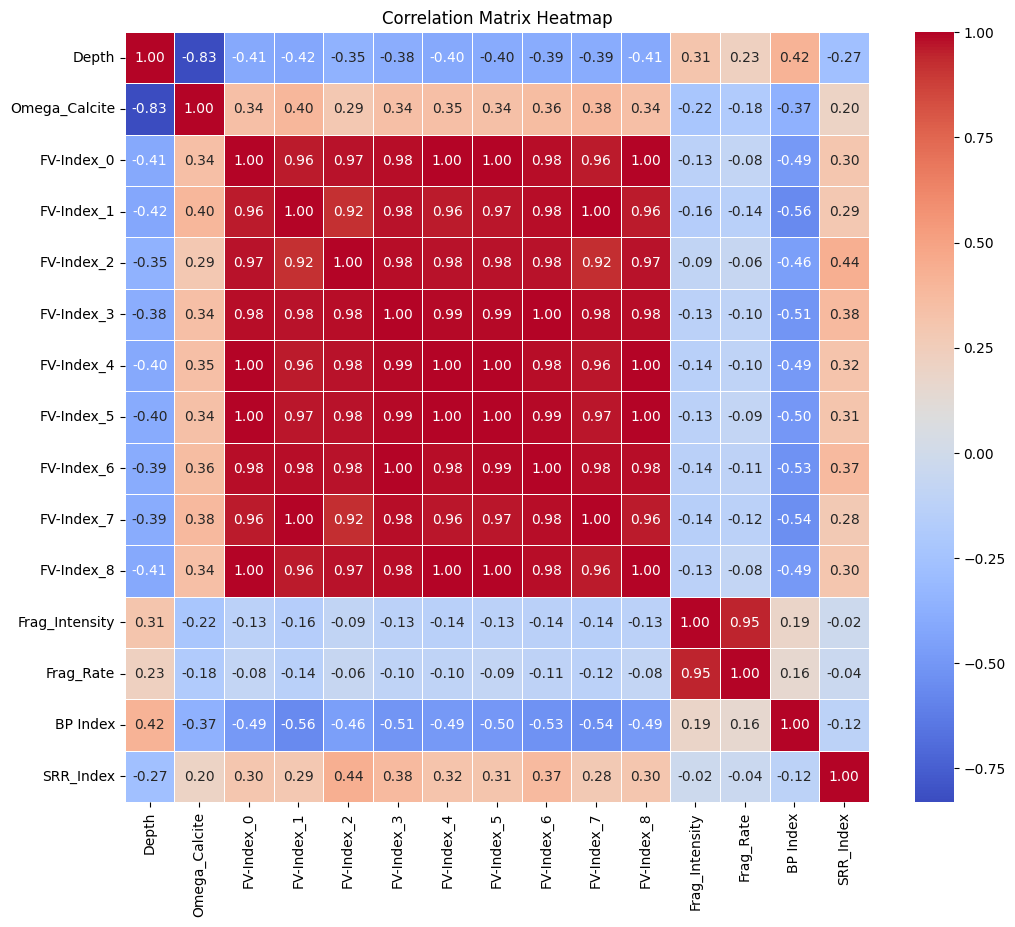

In [52]:
# Compute the correlation matrix
correlation_matrix = merged_tests[['Depth', 'Omega_Calcite', 'FV-Index_0', 'FV-Index_1', 
                                   'FV-Index_2', 'FV-Index_3', 'FV-Index_4', 'FV-Index_5', 
                                   'FV-Index_6', 'FV-Index_7', 'FV-Index_8', 'Frag_Intensity', 
                                   'Frag_Rate', 'BP Index', 'SRR_Index']].corr()

# Create a DataFrame for the correlation matrix
correlation_df = pd.DataFrame(correlation_matrix)

# Generate a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

### Correlation Matrix Heatmap (Prev calculations)

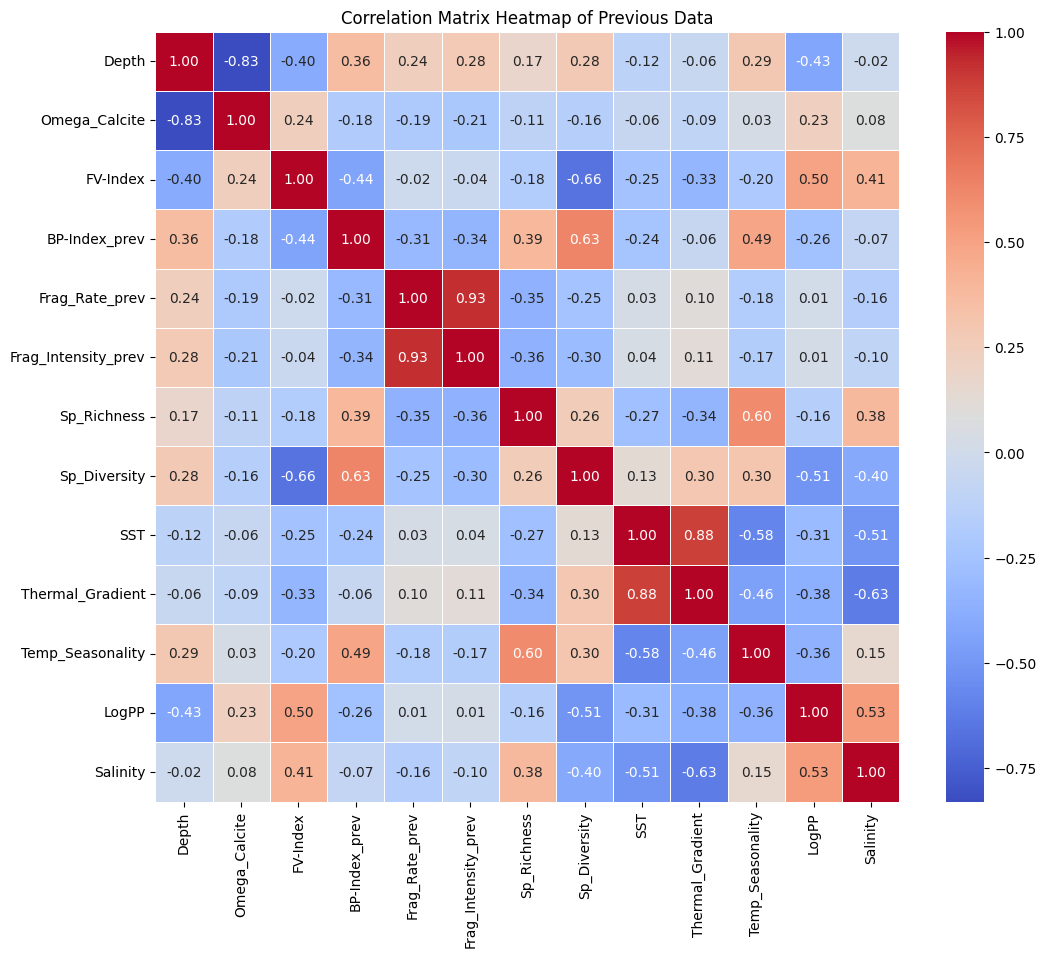

In [53]:
# Compute the correlation matrix
correlation_matrix_base = test_data_2[['Depth', 'Omega_Calcite', 'FV-Index', 'BP-Index_prev', 
       'Frag_Rate_prev', 'Frag_Intensity_prev',  'Sp_Richness',
       'Sp_Diversity', 'SST', 'Thermal_Gradient',
       'Temp_Seasonality', 'LogPP', 'Salinity']].corr()

# Create a DataFrame for the correlation matrix
correlation_df_base = pd.DataFrame(correlation_matrix_base)

# Generate a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_df_base, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap of Previous Data')
plt.show()

### Correlation Matrix Combined (New & Prev)

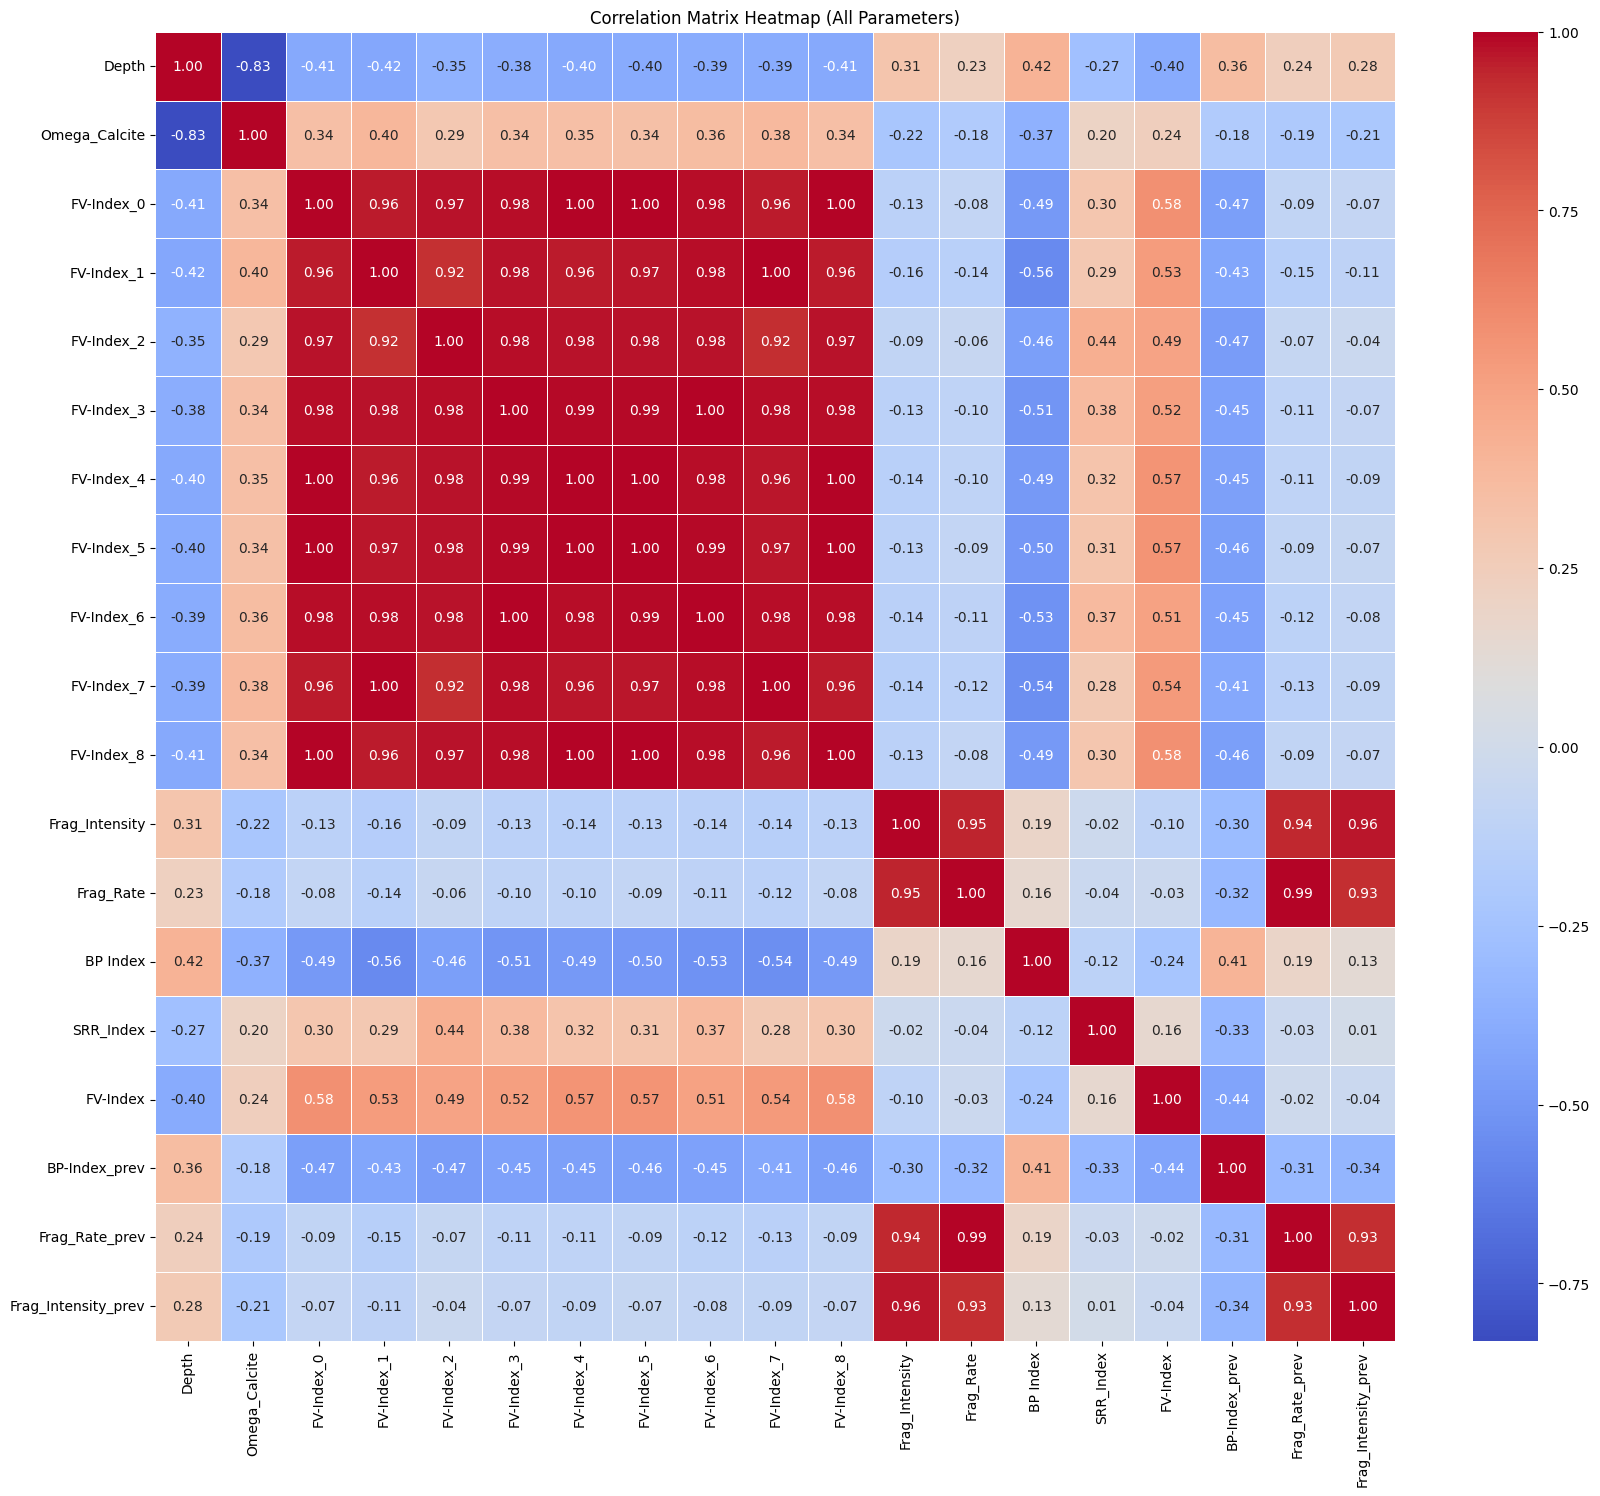

In [54]:
from scipy.stats import pearsonr

# Define the variables of interest
variables = ['Depth', 'Omega_Calcite', 'FV-Index_0', 'FV-Index_1', 'FV-Index_2', 'FV-Index_3',
             'FV-Index_4', 'FV-Index_5', 'FV-Index_6', 'FV-Index_7', 'FV-Index_8', 
             'Frag_Intensity', 'Frag_Rate', 'BP Index', 'SRR_Index',
             'FV-Index', 'BP-Index_prev', 'Frag_Rate_prev',
             'Frag_Intensity_prev',]

# Initialize lists to store the results
r_values = []
r_squared_values = []
p_values = []

# Compute the correlation coefficients, R-squared values, and p-values
for var1 in variables:
    for var2 in variables:
        if var1 != var2:
            r, p = pearsonr(merged_tests_all[var1], merged_tests_all[var2])
            r_squared = r**2
            r_values.append((var1, var2, r))
            r_squared_values.append((var1, var2, r_squared))
            p_values.append((var1, var2, p))

# Create DataFrames for the results
r_df = pd.DataFrame(r_values, columns=['Variable 1', 'Variable 2', 'Correlation Coefficient'])
r_squared_df = pd.DataFrame(r_squared_values, columns=['Variable 1', 'Variable 2', 'R-squared'])
p_df = pd.DataFrame(p_values, columns=['Variable 1', 'Variable 2', 'P-value'])

# Merge the DataFrames
results_df = pd.merge(r_df, r_squared_df, on=['Variable 1', 'Variable 2'])
results_df = pd.merge(results_df, p_df, on=['Variable 1', 'Variable 2'])

# Compute the correlation matrix for the heatmap
correlation_matrix_all = merged_tests_all[variables].corr()

# Create a DataFrame for the correlation matrix
correlation_df_all = pd.DataFrame(correlation_matrix_all)

# Generate a heatmap
plt.figure(figsize=(20, 17))
sns.heatmap(correlation_df_all, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap (All Parameters)')
plt.show()

In [55]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_rows', None)

# View 'Correlation Coefficient', 'R-squared', and 'P-value'
results_df

,Variable 1,Variable 2,Correlation Coefficient,R-squared,P-value
0,Depth,Omega_Calcite,-0.830126,0.689109,7.362846e-17
1,Depth,FV-Index_0,-0.405783,0.164660,1.067451e-03
2,Depth,FV-Index_1,-0.419328,0.175836,6.928185e-04
3,Depth,FV-Index_2,-0.354921,0.125969,4.646681e-03
4,Depth,FV-Index_3,-0.379926,0.144344,2.320986e-03
5,Depth,FV-Index_4,-0.403664,0.162945,1.140282e-03
6,Depth,FV-Index_5,-0.397533,0.158032,1.376966e-03
7,Depth,FV-Index_6,-0.392146,0.153778,1.620370e-03
8,Depth,FV-Index_7,-0.390753,0.152688,1.689282e-03
9,Depth,FV-Index_8,-0.405797,0.164671,1.066995e-03


In [56]:
# merged_tests_all.to_csv('dissolution_indices_2.csv')